## 1. Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import pytensor          # Crucial: Import base pytensor for access to pytensor.scan
import pytensor.tensor as pt
import arviz as az

## 1. Get data

In [2]:
# Read datasets
df_polaris = pd.read_csv('01_polaris_hotline_signals_fy2013_2024.csv')

In [3]:
# Explore shapes
print('Initial shape polaris: ',df_polaris.shape )

Initial shape polaris:  (12, 5)


In [4]:
print('Head polaris:')
display(df_polaris.head(3))

Head polaris:


,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified
0,2013,32438,NaN,2641,4796
1,2014,39134,NaN,2602,5166
2,2015,36916,NaN,3487,5418


## 2. Explore polaris dataset

In [5]:
df_polaris.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   fiscal_year                      12 non-null     int64  
 1   total_signals                    12 non-null     int64  
 2   substantive_signals              7 non-null      float64
 3   signals_from_potential_victims   12 non-null     int64  
 4   potential_situations_identified  12 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 612.0 bytes


In [6]:
# Total number of rows
total_rows = df_polaris.shape[0]
# Get null total number of null values by column
df_aux = df_polaris.isna().sum()
# Transfrom to dataframe
df_aux = df_aux.to_frame()
df_aux = df_aux.rename(columns={0: "Missing"})
df_aux.reset_index(inplace=True)
df_aux['%missing_value'] = round((df_aux['Missing'] / total_rows)*100,0)
df_aux

,index,Missing,%missing_value
0,fiscal_year,0,0.0
1,total_signals,0,0.0
2,substantive_signals,5,42.0
3,signals_from_potential_victims,0,0.0
4,potential_situations_identified,0,0.0


Almost have of the substantive_signals have missing values in the dataset, the other columns don't present missing information.

In [7]:
print('Number of years in the dataset: ',df_polaris['fiscal_year'].nunique())
print('Years: ',df_polaris['fiscal_year'].unique() )

Number of years in the dataset:  12
Years:  [2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]


In [8]:
# Calculate the percentage of signals report by victims
df_polaris['signals_victims_percentage'] = round(df_polaris['signals_from_potential_victims'] / df_polaris['total_signals'],4)*100
# Calculte the the average number of a single trafficking situation generate by multiple signals.
df_polaris['avg_signals_identified'] =  df_polaris['total_signals'] / df_polaris['potential_situations_identified']

In [9]:
display(df_polaris.head(3))

,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified,signals_victims_percentage,avg_signals_identified
0,2013,32438,NaN,2641,4796,8.14,6.763553
1,2014,39134,NaN,2602,5166,6.65,7.575300
2,2015,36916,NaN,3487,5418,9.45,6.813584


In [10]:
df_polaris.head(50)

,fiscal_year,total_signals,substantive_signals,signals_from_potential_victims,potential_situations_identified,signals_victims_percentage,avg_signals_identified
0,2013,32438,NaN,2641,4796,8.14,6.763553
1,2014,39134,NaN,2602,5166,6.65,7.575300
2,2015,36916,NaN,3487,5418,9.45,6.813584
3,2016,54823,NaN,4608,7405,8.41,7.403511
4,2017,68938,NaN,4626,8686,6.71,7.936680
5,2018,116940,47709.0,7136,10658,6.10,10.972040
6,2019,136990,56644.0,10362,11852,7.56,11.558387
7,2020,195100,65959.0,13129,11193,6.73,17.430537
8,2021,219380,66308.0,13538,10983,6.17,19.974506
9,2022,212167,55731.0,10190,10013,4.80,21.189154


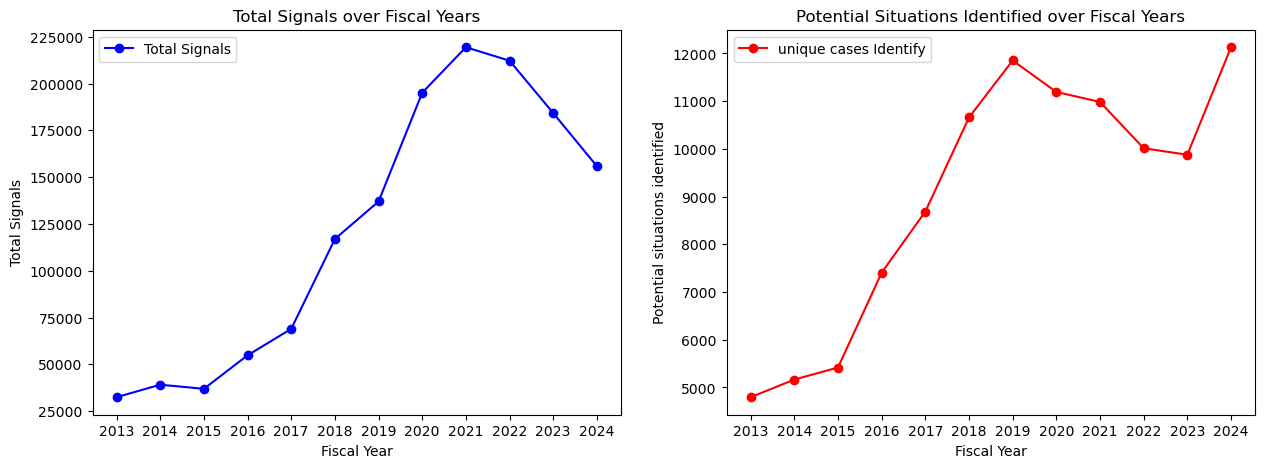

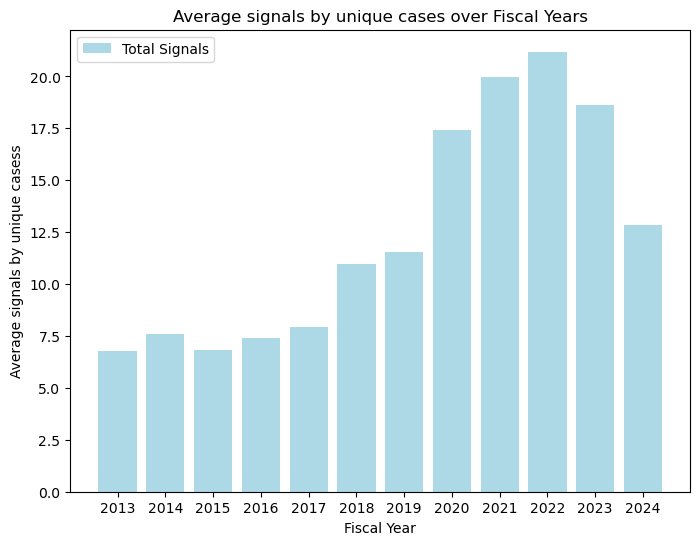

In [11]:
# Graph 1: Create the time series plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(df_polaris['fiscal_year'], df_polaris['total_signals'], marker='o', linestyle='-', color='b', label='Total Signals')
# Add labels and title
ax1.set_title('Total Signals over Fiscal Years')
ax1.set_xlabel('Fiscal Year')
ax1.set_ylabel('Total Signals')
ax1.set_xticks(df_polaris['fiscal_year']) 
#ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

ax2.plot(df_polaris['fiscal_year'], df_polaris['potential_situations_identified'], marker='o', linestyle='-', color='red', label='unique cases Identify')
# Add labels and title
ax2.set_title('Potential Situations Identified over Fiscal Years')
ax2.set_xlabel('Fiscal Year')
ax2.set_ylabel('Potential situations identified')
ax2.set_xticks(df_polaris['fiscal_year']) 
#ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()
plt.savefig('Images/total_signal_potential_situation.png')
plt.show()


# Graph 2: avg_signals_by_unique_cases
plt.figure(figsize=(8, 6)) 
plt.bar(df_polaris['fiscal_year'], df_polaris['avg_signals_identified'], color='lightblue', label='Total Signals')

# Add labels and title
plt.title('Average signals by unique cases over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('Average signals by unique casess')
plt.xticks(df_polaris['fiscal_year']) 
plt.legend()
plt.show()


The timeseries plot shows that the Total Signals have been increasing since 2013 until 2021, with a downward trend from 2021 to 2024. However, the potential situations identified got their highest value in 2024, with 12K victims found, despite a negative trend from 2019 to 2023, probably related to the COVID period. Moreover, we can see that the average signals by case have been between 7.5 to 20, meaning that several people report the same human traffic case. 

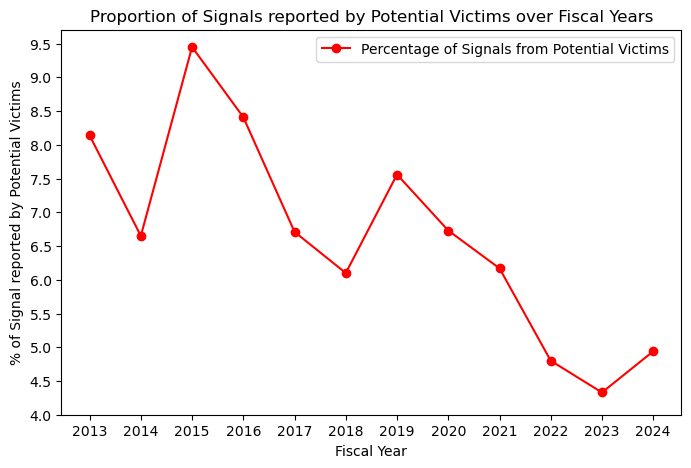

In [12]:
# Graph 2: Create the time series plot
plt.figure(figsize=(8, 5)) 
plt.plot(df_polaris['fiscal_year'], df_polaris['signals_victims_percentage'], marker='o', linestyle='-', color='r', label='Percentage of Signals from Potential Victims')
# Add labels and title
plt.title('Proportion of Signals reported by Potential Victims over Fiscal Years')
plt.xlabel('Fiscal Year')
plt.ylabel('% of Signal reported by Potential Victims')
plt.xticks(df_polaris['fiscal_year']) 
plt.yticks(np.arange(4, 10, 0.5))
#plt.grid(True, linestyle='--', alpha=0.8)
plt.legend()
plt.savefig('Images/proportion_signals_reported.png')
plt.show()

The proportion of signals reported by potential victims has constantly decreased over the last decade, reaching a minimum of 5%. This timeseries plot suggests that the victims have been less listened to, depending more on witnesses, family, friends, law enforcement, or anonymous reporters.

## 2. Modeling (Model 1)

In [13]:
class BayesianStateSpaceDecomp:
    def __init__(self, data_input):
        """Initializes data matrices inside the class instance context."""
        self.df = data_input
        self.years = self.df['fiscal_year'].values
        self.n_periods = len(self.years)
        self.y_obs = self.df['potential_situations_identified'].values.astype(float)
        self.x_intervention = (self.years >= 2018).astype(float)
        
    def execute_mcmc_sampling(self, draws: int = 2000, tune: int = 3000, target_accept: float = 0.95):
        """Compiles the Dynamic Linear Model graph and runs the NUTS sampler."""
        print("[INFO] Constructing PyMC state-space computational graph...")
        with pm.Model() as self.model:
            # Scale Priors
            sigma_obs = pm.HalfNormal("sigma_obs", sigma=1)
            sigma_level = pm.HalfNormal("sigma_level", sigma=1)
            sigma_drift = pm.HalfNormal("sigma_drift", sigma=1)
            beta_fosta = pm.Normal("beta_fosta", mu=0, sigma=1)
            
            # Initial Latent States
            mu_init = pm.Normal("mu_init", mu=self.y_obs[0], sigma=2000)
            delta_init = pm.Normal("delta_init", mu=0, sigma=self.y_obs[0])
            
            # System Innovations (Non-centered parameterization)
            level_innovations = pm.Normal("level_innovations", mu=0, sigma=1, shape=self.n_periods - 1)
            drift_innovations = pm.Normal("drift_innovations", mu=0, sigma=1, shape=self.n_periods - 1)
            
            # State Transition Function for PyTensor Scan
            def state_transition_step(level_inn, drift_inn, prev_level, prev_drift, s_level, s_drift):
                next_drift = prev_drift + drift_inn * s_drift
                next_level = prev_level + next_drift + level_inn * s_level
                return next_level, next_drift

            # FIX: Swapped pt.scan for pytensor.scan to match PyTensor v5 specifications
            states, _ = pytensor.scan(
                fn=state_transition_step,
                sequences=[level_innovations, drift_innovations],
                outputs_info=[mu_init, delta_init],
                non_sequences=[sigma_level, sigma_drift],
                n_steps=self.n_periods - 1
            )
            
            mu_states = pt.concatenate([[mu_init], states[0]])
            pm.Deterministic("latent_trend", mu_states)
            policy_impact = pm.Deterministic("policy_impact", beta_fosta * self.x_intervention)
            
            # Observation Likelihood
            expected_value = mu_states + policy_impact
            pm.Normal("y_likelihood", mu=expected_value, sigma=sigma_obs, observed=self.y_obs)
            
            print("[INFO] Initiating NUTS sampling sequence...")
            self.idata = pm.sample(draws=draws, tune=tune, target_accept=target_accept, random_seed=42)
            
        return self.idata

    def evaluate_diagnostics(self):
        """Evaluates convergence using R-hat."""
        print("\n=== BAYESIAN MCMC CONVERGENCE DIAGNOSTICS ===")
        summary = az.summary(self.idata, var_names=["beta_fosta", "sigma_obs", "sigma_level"])
        display(summary)
        
    def export_residual_signal(self) -> pd.DataFrame:
        """Extracts the filtered demand signature by stripping trends and policy jumps."""
        post_trend = self.idata.posterior["latent_trend"].mean(dim=("chain", "draw")).values
        post_impact = self.idata.posterior["policy_impact"].mean(dim=("chain", "draw")).values
        residual_signal = self.y_obs - (post_trend + post_impact)
        
        return pd.DataFrame({
            "fiscal_year": self.years,
            "observed_situations": self.y_obs,
            "estimated_base_trend": post_trend,
            "policy_shock_component": post_impact,
            "filtered_demand_residual": residual_signal
        })

# --- EXECUTION BLOCK ---
if __name__ == "__main__":
    
    # Call functions
    decomposer = BayesianStateSpaceDecomp(df_polaris)
    idata = decomposer.execute_mcmc_sampling()
    decomposer.evaluate_diagnostics()
    
    results = decomposer.export_residual_signal()
    print("\n--- SAMPLE EXTRACTED STRUCTURAL RESIDUALS ---")
    display(results.tail(4))

[INFO] Constructing PyMC state-space computational graph...
[INFO] Initiating NUTS sampling sequence...


/var/folders/n5/47rwg6rs4rs2yz78ys0fy1vw0000gn/T/ipykernel_19045/2230780226.py:35: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  states, _ = pytensor.scan(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma_obs, sigma_level, sigma_drift, beta_fosta, mu_init, delta_init, level_innovations, drift_innovations]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 126 seconds.



=== BAYESIAN MCMC CONVERGENCE DIAGNOSTICS ===


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_fosta,0.340,1.018,-1.580,2.202,0.008,0.013,15256.0,5763.0,1.0
sigma_obs,37.431,0.846,35.861,39.017,0.010,0.008,6718.0,6416.0,1.0
sigma_level,1.624,1.222,0.001,3.836,0.018,0.013,4075.0,3914.0,1.0



--- SAMPLE EXTRACTED STRUCTURAL RESIDUALS ---


,fiscal_year,observed_situations,estimated_base_trend,policy_shock_component,filtered_demand_residual
8,2021,10983.0,10826.070230,0.339818,156.589952
9,2022,10013.0,10421.131491,0.339818,-408.471309
10,2023,9877.0,10606.928431,0.339818,-730.268249
11,2024,12130.0,11505.554818,0.339818,624.105364


In [14]:
# Check results
display(results)

,fiscal_year,observed_situations,estimated_base_trend,policy_shock_component,filtered_demand_residual
0,2013,4796.0,4569.309461,0.000000,226.690539
1,2014,5166.0,5142.926071,0.000000,23.073929
2,2015,5418.0,5973.247336,0.000000,-555.247336
3,2016,7405.0,7345.971919,0.000000,59.028081
4,2017,8686.0,8911.661258,0.000000,-225.661258
5,2018,10658.0,10390.429439,0.339818,267.230743
6,2019,11852.0,11243.529805,0.339818,608.130377
7,2020,11193.0,11235.728509,0.339818,-43.068327
8,2021,10983.0,10826.070230,0.339818,156.589952
9,2022,10013.0,10421.131491,0.339818,-408.471309


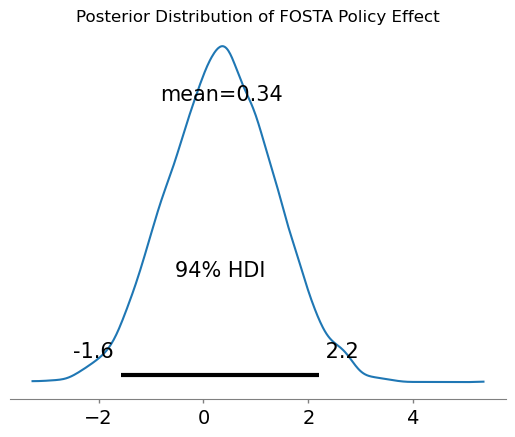

In [15]:
# Posterior distribution + trace side by side
az.plot_posterior(idata, var_names=["beta_fosta"], hdi_prob=0.94)
plt.title("Posterior Distribution of FOSTA Policy Effect")
plt.savefig('Images/posterior_distribution.png')
plt.show()

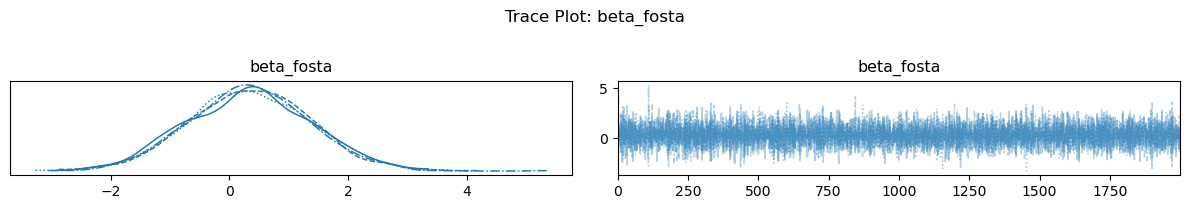

In [16]:
az.plot_trace(idata, var_names=["beta_fosta"])
plt.suptitle("Trace Plot: beta_fosta", y=1.02)
plt.tight_layout()
plt.savefig('Images/trace_plot.png')
plt.show()

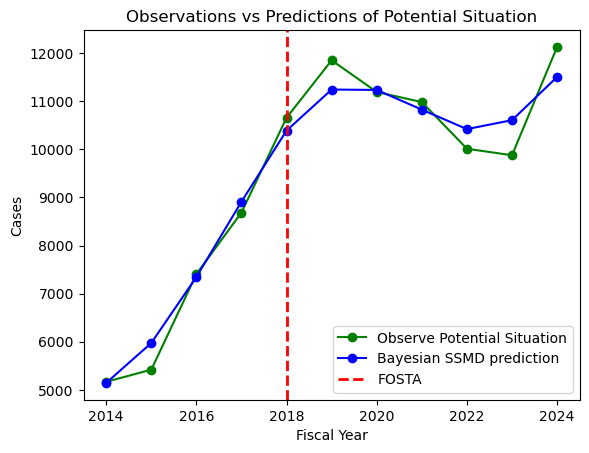

In [17]:
df_aux = results[results['fiscal_year'] > 2013]
plt.plot(df_aux['fiscal_year'],df_aux['observed_situations'],marker='o', linestyle='-', color='green', label='Observe Potential Situation')
plt.plot(df_aux['fiscal_year'],df_aux['estimated_base_trend'],marker='o', linestyle='-', color='blue', label='Bayesian SSMD prediction')
plt.axvline(x=2018, color='red', linestyle='--', linewidth=2, label='FOSTA')

plt.title('Observations vs Predictions of Potential Situation')
plt.xlabel('Fiscal Year')
plt.ylabel('Cases')
plt.legend()
plt.savefig('Images/obs_vs_pred.png')
plt.show()